In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Example DataFrame
df = pd.DataFrame({
    "x": [0.000000, 0.714286, 1.428571, 2.142857, 2.857143, 3.571429, 4.285714, 5.000000, 5.714286, 6.428571],
    "y_true": [1.000000, 2.428571, 3.857143, 5.285714, 6.714286, 8.142857, 9.571429, 11.000000, 12.428571, 13.857143],
    "y_noisy": [1.993428, 2.152043, 5.152520, 8.331774, 6.245979, 7.674583, 12.729854, 12.534869, 11.489623, 14.942263],
    "y_pred_overfit": [2.022717, 1.905389, 6.003958, 6.892196, 7.110060, 8.613044, 10.954319, 12.721760, 13.265723, 13.348182]
})


# RIDGE

 - # OVER FITING

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split as t

x1 , x2 , y1 , y2 =  t(df.iloc[:,:-1] , df.iloc[:,-1] , test_size = 0.3 ,random_state =12 )

In [20]:
lr  = LinearRegression()


In [21]:
lr.fit(x1,y1)

LinearRegression()

In [22]:
from sklearn.metrics import r2_score

In [25]:
r2_score(y1 , lr.predict(x1))

0.9916866725191991

In [28]:
from sklearn.model_selection import learning_curve
import numpy as np

In [29]:
train_sizes, train_scores, val_scores = learning_curve(
    lr, x1, y1, cv=5, scoring='neg_mean_squared_error', train_sizes=np.linspace(0.1, 1.0, 5))

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:2180: RuntimeWarning: Removed duplicate entries from 'train_sizes'. Number of ticks will be less than the size of 'train_sizes': 4 instead of 5.
  warnings.warn(


In [34]:
train_scores

array([[-0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
        -0.00000000e+00, -0.00000000e+00],
       [-0.00000000e+00, -1.28189897e-30, -1.28189897e-30,
        -1.28189897e-30, -1.28189897e-30],
       [-4.20725816e-30, -1.90641385e-30, -6.31088724e-30,
        -6.31088724e-30, -6.31088724e-30],
       [-8.87645715e-03, -1.35767227e-04, -1.62035891e-01,
        -1.42328894e-01, -1.42328894e-01]])

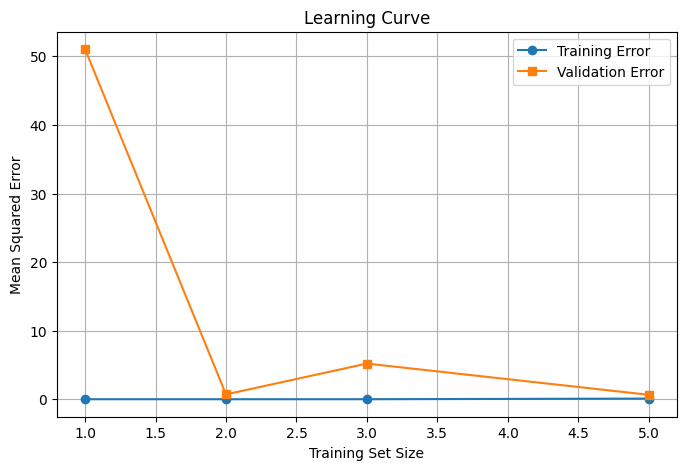

In [33]:

# ✅ 1. Validation Curve (also called hyperparameter tuning curve)
# 📌 What it is:
# A plot of model performance (e.g., accuracy, MSE, R²) as you vary a specific hyperparameter (like alpha in Ridge or max_depth in a tree).

# 🔧 Used For:
# Tuning one hyperparameter

# Helps find optimal value
train_error_mean = -np.mean(train_scores, axis=1)
val_error_mean = -np.mean(val_scores, axis=1)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_error_mean, label="Training Error", marker='o')
plt.plot(train_sizes, val_error_mean, label="Validation Error", marker='s')
plt.title("Learning Curve")
plt.xlabel("Training Set Size")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Pattern	Training Error	Validation Error	Problem Type	Action
# Small gap, both low	✅ Low	✅ Low	Good Fit	—
# Large gap (val high)	✅ Low	❌ High	Overfitting	Regularization, more data
# Both high	❌ High	❌ High	Underfitting	Use more complex model/features

In [ ]:
# If validation error is much higher than training error → ❌ Overfitting

# If both errors are high and close → ❌ Underfitting

# If both are low and close → ✅ Well-generalized model

In [ ]:
# Why np.linspace(0.1, 1.0, 5) in Learning Curve?
# This line:

# python
# Copy
# Edit
# train_sizes = np.linspace(0.1, 1.0, 5)
# means:

# “Train the model on 5 different portions of the dataset, from 10% to 100%.”

# 🔍 What the values mean:
# 0.1 = 10% of data

# 1.0 = 100% of data

# 5 = split this range into 5 equally spaced values

# Result:

# python
# Copy
# Edit
# array([0.1 , 0.325, 0.55 , 0.775, 1.0])
# So the model will be trained on:

# 10% of training data

# 32.5%

# 55%

# 77.5%

# 100%

# 🎯 Why Do This?
# Because the goal of a learning curve is to answer:

# “How does my model’s performance change as I increase training data?”

# 💡 Example Use Case
# Let’s say you have 1000 training samples.

# With np.linspace(0.1, 1.0, 5), the learning curve will train on:

# Step	Training Set Size
# 1	100 samples
# 2	325 samples
# 3	550 samples
# 4	775 samples
# 5	1000 samples

# And plot training/validation error for each.

# 🧠 Why Start at 0.1 (10%)?
# Starting from 0.1 lets us see how the model learns when it has very little data.

# We don't start at 0 — you can't train with zero data!

# Going to 1.0 ensures we test with full training data at the end.

# ✅ Summary
# Code	Meaning
# np.linspace(0.1, 1.0, 5)	5 steps from 10% to 100% of training data
# Used in learning curve to	See how performance changes with more data

# Let me know your dataset size — I can recommend the ideal train_sizes array for your case!









# Ask ChatGPT


In [36]:
from sklearn.model_selection import learning_curve

In [41]:
train_size , train_score , test_score = learning_curve( lr  , x1 , y1 , scoring = "neg_mean_squared_error" , train_sizes = np.linspace(0.1,1 , 5))

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:2180: RuntimeWarning: Removed duplicate entries from 'train_sizes'. Number of ticks will be less than the size of 'train_sizes': 4 instead of 5.
  warnings.warn(


In [43]:
trs = -np.mean(train_score , axis = 1)
tts = -np.mean(test_score , axis = 1)

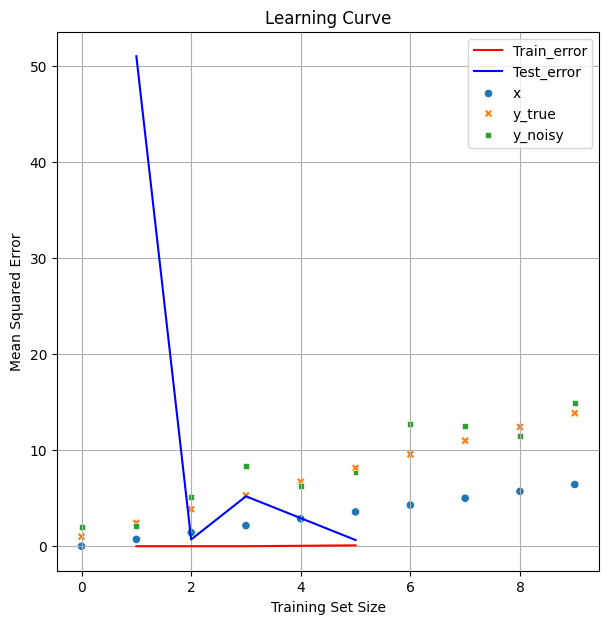

In [53]:
plt.figure(figsize=(7,7))
plt.plot(train_size ,  trs , color ="red" , label = "Train_error")
plt.plot(train_size ,  tts , color ="blue" , label = "Test_error")
plt.title("Learning Curve")
plt.xlabel("Training Set Size")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(True)
plt.show()

plt.show()

In [54]:
from sklearn.linear_model import Ridge

In [56]:
l2 = Ridge(alpha = 10  , fit_intercept = True, max_iter=1000 )
l2.fit(x1,y1)

Ridge(alpha=10, max_iter=1000)

In [57]:
r2_score(y2  , l2.predict(x2))

0.5089015356326316

In [59]:
train_size , train_sc , test_sc = learning_curve(l2 , x1 , y1 , cv = 5,scoring="neg_mean_squared_error" ,train_sizes = np.linspace(0.1 , 1 , 5))

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:2180: RuntimeWarning: Removed duplicate entries from 'train_sizes'. Number of ticks will be less than the size of 'train_sizes': 4 instead of 5.
  warnings.warn(


In [60]:
t1 = -np.mean(train_score , axis = 1)
t2 = -np.mean(test_score , axis = 1)

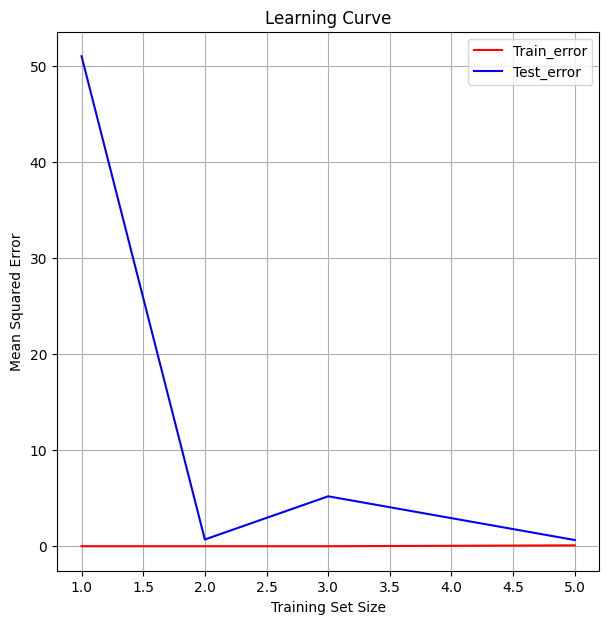

In [61]:
plt.figure(figsize=(7,7))
plt.plot(train_size ,  t1 , color ="red" , label = "Train_error")
plt.plot(train_size ,  t2b , color ="blue" , label = "Test_error")
plt.title("Learning Curve")
plt.xlabel("Training Set Size")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(True)
plt.show()

plt.show()

In [62]:
from sklearn.preprocessing import PolynomialFeatures

In [76]:
pf = PolynomialFeatures(degree=3)
pf.fit(x1 , y1)

PolynomialFeatures(degree=3)

In [77]:
x_1 = pf.transform(x1)
x_2 = pf.transform(x2)

In [78]:
x_1 = pd.DataFrame(data = x_1)
x_2 = pd.DataFrame(data = x_2)



In [72]:
from sklearn.linear_model import LinearRegression , Ridge

In [79]:
la =  LinearRegression()
lb = Ridge(max_iter = 100 , alpha =  10)
la.fit(x_1 , y1)
lb.fit(x_1 , y1)


Ridge(alpha=10, max_iter=100)

In [80]:
r2_score(y2 , la.predict(x_2))

-3.8084243535322235

In [81]:
r2_score(y2 , lb.predict(x_2))

-2.157889709437878

# Bias Variance

In [82]:
from mlxtend.evaluate import bias_variance_decomp

array([[ 2.022717],
       [ 7.11006 ],
       [13.348182],
       [ 6.892196],
       [ 6.003958],
       [ 1.905389],
       [10.954319]])

In [92]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from mlxtend.evaluate import bias_variance_decomp

# Set alphas to test multiple values
alphas = np.linspace(10, 100, 10)  # 10 values between 10 and 100

# Prepare lists to collect metrics
bias = []
var = []
loss = []

# Make sure y is reshaped properly
a = y1.values.ravel()  # .ravel() or .flatten() is safer than reshape(-1, 1)
b = y2.values.ravel()

# Polynomial features (you had degree=0 which makes no sense — minimum degree should be 1)
poly = PolynomialFeatures(degree=2)
x1_poly = poly.fit_transform(x1)
x2_poly = poly.transform(x2)

# Loop through alpha values and compute bias/variance
for i in alphas:
    model = Ridge(alpha=i)
    avg_loss, avg_bias, avg_var = bias_variance_decomp(
        model, x1_poly, a, x2_poly, b,
        loss='mse',
        num_rounds=50,
        random_seed=13
    )
    bias.append(avg_bias)
    var.append(avg_var)
    loss.append(avg_loss)
#    num_rounds = Number of Resampling Rounds
# It defines how many times the training set is randomly sampled to compute average bias, variance, and loss.


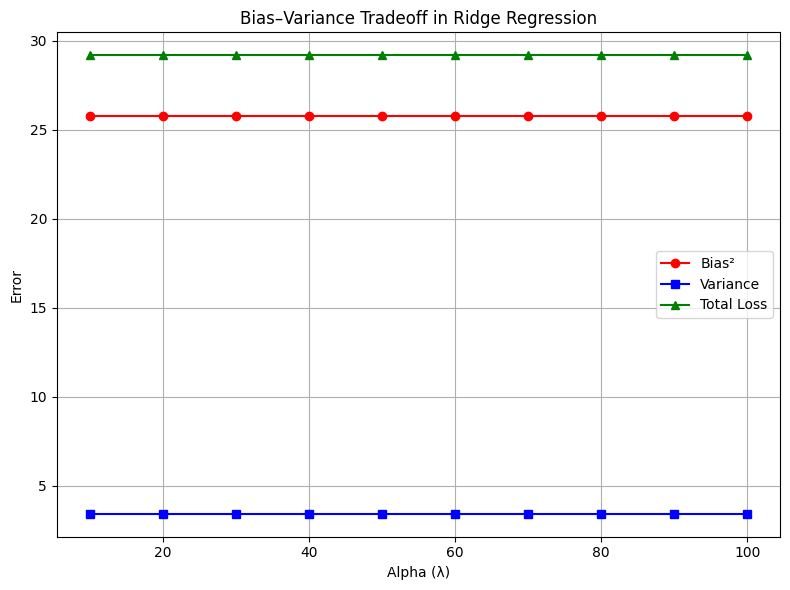

In [96]:
pBlt.figure(figsize=(8, 6))
plt.plot(alphas, bias, label="Bias²", color='red', marker='o')
plt.plot(alphas, var, label="Variance", color='blue', marker='s')
plt.plot(alphas, loss, label="Total Loss", color='green', marker='^')

plt.title("Bias–Variance Tradeoff in Ridge Regression")
plt.xlabel("Alpha (λ)")
plt.ylabel("Error")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

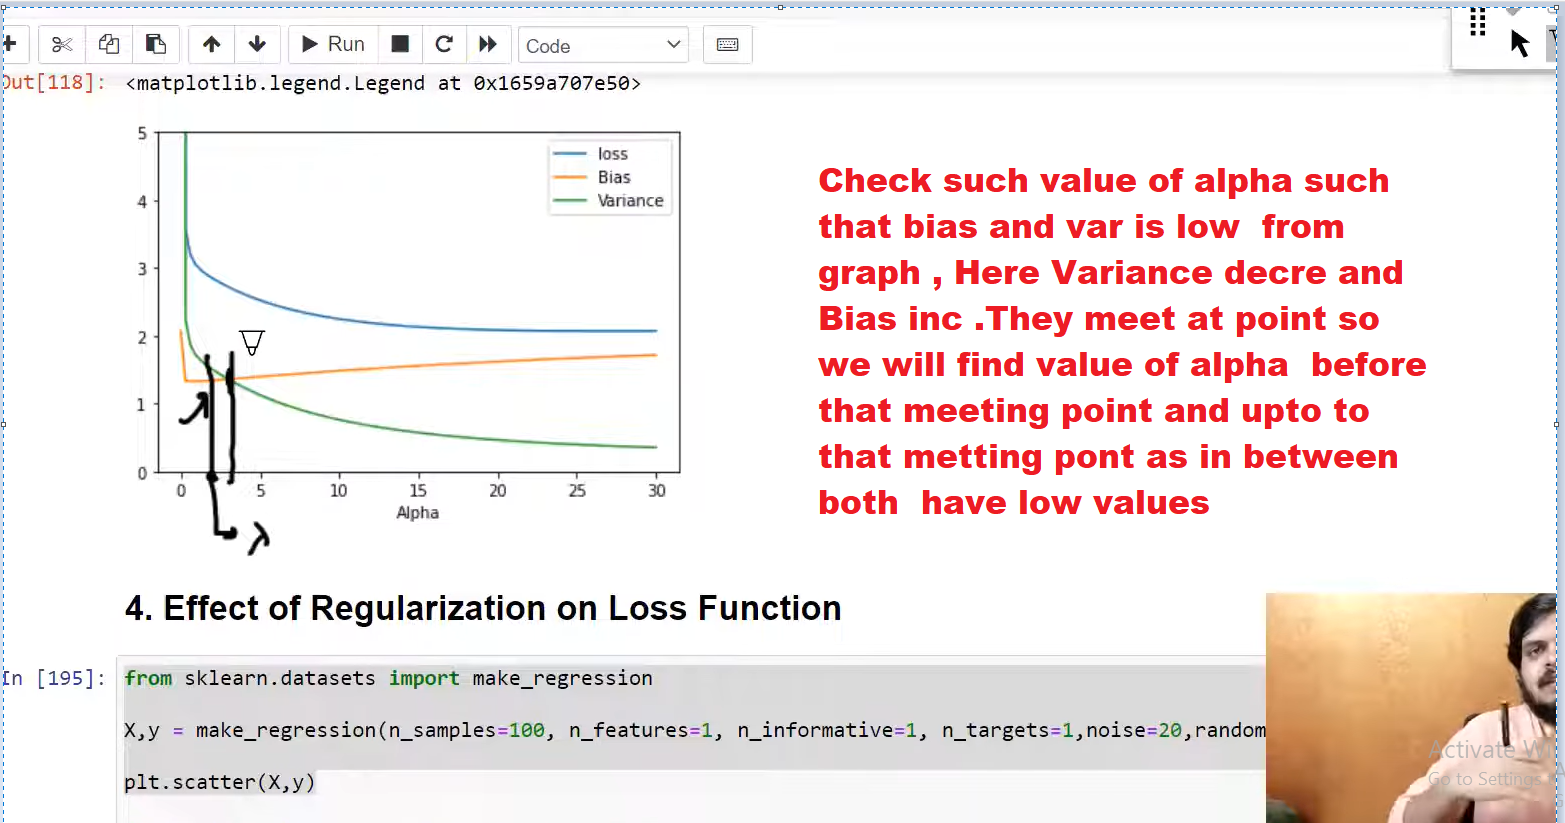

# LASSO
- # UNDER FITTING

In [ ]:
# How to Detect Underfitting — Signs & Checks
# 🔬 Check	What to Look For
# 📉 Low training accuracy / R²	Model doesn't even fit the training data well
# 📉 Train error ≈ Test error, both high	Both errors are bad and close → model too simple
# 📈 High bias, low variance	From bias–variance analysis
# 🧪 Validation curves	Flat and high validation + training error across all model complexities
# 📊 Learning curves	Both training and test errors are high and do not converge as data size increases
# ⚠️ Linear model on complex nonlinear data	e.g. fitting y = x² with linear regression

In [98]:
from sklearn.linear_model import Lasso , SGDRegressor

In [99]:
ls = Lasso(alpha = 20 , max_iter = 1000 , fit_intercept = True)

In [108]:
lg = SGDRegressor(eta0=0.01,penalty = "l2" ,alpha = 30 , tol = 1e-3 ,fit_intercept=True  )

# Elastic NET

In [112]:
# L1 RATIO AND LAMBDA is hyper paramteter
# lambda = a+b
# l1_ratio = a/a+b

# used when u dont 09 which features are imp
# used when input has multi colinearity
from sklearn.linear_model import ElasticNet
en =ElasticNet(alpha = 0.1 , l1_ratio  =0.2)

sg = SGDRegressor(eta0 = 0.1 , tol = 1e-3 ,penalty = "elasticnet" , l1_ratio = 0.15)

# l1_ratio = 0.15 means:

# 15% L1 regularization

# 85% L2 regularization
